# GPT2 cosine similarities

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# import GPT2 model and extract embeddings matrix

In [2]:
from transformers import GPT2Model, GPT2Tokenizer

# pretrained GPT-2 model and tokenizer
gpt2 = GPT2Model.from_pretrained('gpt2')
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')

# get the word token embeddings matrix
embeddings = gpt2.wte.weight.detach().numpy()

/Users/shre/courses/llm_deep_dive/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# the cosmic banana

In [3]:
# words of interest
word1 = "banana"
word2 = "apple"
word3 = "cosmic"

# decomposition
for w in [word1, word2, word3]:
    t = tokenizer.encode(w)
    print(f'"{w}" comprises {len(t)} tokens:\n   {[tokenizer.decode(i) for i in t]}\n')

"banana" comprises 2 tokens:
   ['ban', 'ana']

"apple" comprises 1 tokens:
   ['apple']

"cosmic" comprises 2 tokens:
   ['cos', 'mic']



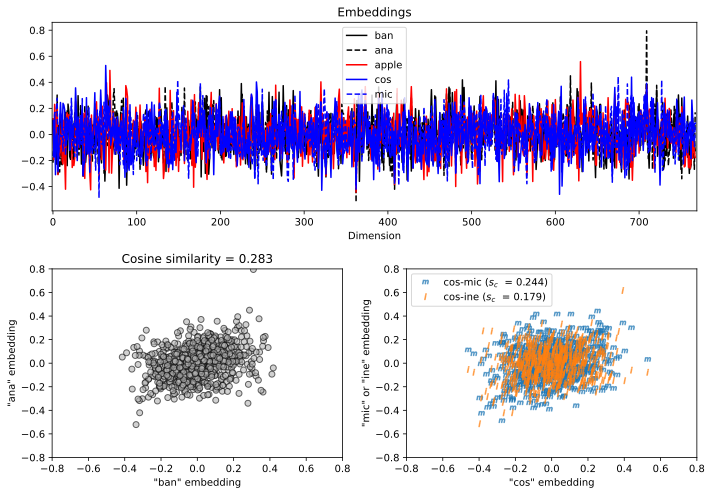

In [4]:
# setup the figure subplot geometry
fig = plt.figure(figsize=(10,7))
gs = GridSpec(2,2)
ax0 = fig.add_subplot(gs[0, :])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1])

# plot the embeddings by dimension
colors = 'krb'
linestyles = ['-', '--', '-.', ':']

for idx, word in enumerate([word1, word2, word3]):
    wordidx = tokenizer.encode(word)
    for j in range(len(wordidx)):
        ax0.plot(embeddings[wordidx[j], :], 
                 linestyle=linestyles[j], 
                 color=colors[idx], 
                 label=tokenizer.decode(wordidx[j]))

ax0.set(xlabel="Dimension", title="Embeddings", xlim=[-1, embeddings.shape[1]+1])
ax0.legend()

# cosine similarity between 'ban' and 'ana'
v1 = embeddings[tokenizer.encode('ban')]
v2 = embeddings[tokenizer.encode('ana')]
cossim = np.sum(v1*v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

# plot the embeddings by each other
ax1.plot(v1, v2, 'ko', markerfacecolor=[.7,.7,.7,.6])
ax1.set(xlim=[-.8, .8],
        ylim=[-.8,.8],
        xlabel='"ban" embedding',
        ylabel='"ana" embedding',
        title=f"Cosine similarity = {cossim:.3f}")

# plot the "cos" for two endings
for s in ['mic', 'ine']:
    # cosine similarity
    v1 = embeddings[tokenizer.encode('cos')].squeeze()
    v2 = embeddings[tokenizer.encode(s)].squeeze()
    cossim = np.sum(v1*v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

    # plot
    ax2.plot(v1, v2, marker=f'${s[0]}$', linestyle='none', alpha=.6, label=f'cos-{s} ($s_c$  = {cossim:.3f})')

ax2.legend(fontsize=10)
ax2.set(xlim=[-.8,.8],
        ylim=[-.8,.8],
        xlabel='"cos" embedding',
        ylabel='"mic" or "ine" embedding')

# final touches
plt.tight_layout()
plt.show()

# find tokens with similar embeddings

In [7]:
tokenizer.encode(' Fashion')

[30958]

In [8]:
# get seed index and embedding vector
seed = tokenizer.encode(' Fashion')
seedvect = embeddings[seed].squeeze()
seedvectNorm = np.linalg.norm(seedvect)

# calculate cosine similarity to all other tokens in a for-loop
cossims = np.zeros(embeddings.shape[0])
for idx, v in enumerate(embeddings):
    cossims[idx] = np.sum(seedvect * v) / (seedvectNorm * np.linalg.norm(v))

# and visualize
plt.figure(figsize=(10,4))
plt.plot(cossims, 'k.', alpha=.6, markerfacecolor='w')
plt.gca().set(xlim=[-5,len(cossims)+5],
              xlabel='Token index',
              ylabel='Cosine similarity',
              title='Cosine similarity to " Fashion"')

# top 20 largest cosine-similarities
top20 = np.argsort(cossims)[-20:]

for i in top20:
    plt.plot(i, cossims[i], 'ms', markersize=4, alpha=.6)

plt.show()

In [9]:
# tokens closest to " Fashion"
for n in top20[::-1]:
  print(f'"{tokenizer.decode(n)}" with cosine similarity {cossims[n]:.3f}')

" Fashion" with cosine similarity 1.000
"fashion" with cosine similarity 0.685
" fashion" with cosine similarity 0.674
"ashion" with cosine similarity 0.605
" Clothing" with cosine similarity 0.549
" fashionable" with cosine similarity 0.533
" Costume" with cosine similarity 0.523
" stylish" with cosine similarity 0.511
" clothing" with cosine similarity 0.507
" garments" with cosine similarity 0.501
" wardrobe" with cosine similarity 0.498
" Beauty" with cosine similarity 0.498
" sewing" with cosine similarity 0.497
" apparel" with cosine similarity 0.489
" Style" with cosine similarity 0.488
" dresses" with cosine similarity 0.485
" Shopping" with cosine similarity 0.485
" Dress" with cosine similarity 0.483
" Cosmetic" with cosine similarity 0.482
" garment" with cosine similarity 0.481


# One-to-all cosine similarity via linear algebra

In [10]:
# normalize entire embedding matrix (in a new variable)
Enorm = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)

# cosine similarity matrices
cossims2 = Enorm[seed] @ Enorm.T

In [11]:
print(f'Size of for-loop version:   {cossims.shape}')
print(f'Size of vectorized version: {cossims2.shape}')

# remove singleton dimension
cossims2 = np.squeeze(cossims2)

# inspect again
print('\n** After squeezing:')
print(f'Size of for-loop version:   {cossims.shape}')
print(f'Size of vectorized version: {cossims2.shape}')

Size of for-loop version:   (50257,)
Size of vectorized version: (1, 50257)

** After squeezing:
Size of for-loop version:   (50257,)
Size of vectorized version: (50257,)


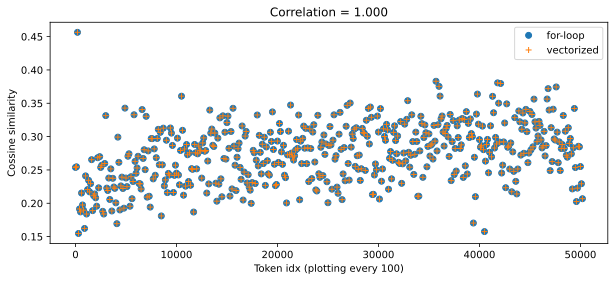

In [12]:
plt.figure(figsize=(10,4))
plt.plot(range(0,len(cossims),100), cossims[::100], 'o', label='for-loop')
plt.plot(range(0,len(cossims),100), cossims2[::100], '+', label='vectorized')

plt.legend()
plt.gca().set(xlabel='Token idx (plotting every 100)',
              ylabel='Cossine similarity',
              title=f'Correlation = {np.corrcoef(cossims,cossims2)[0,1]:.3f}')
plt.show()